<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_9_2_1_RF_TFIDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification on Social Cognitive Dimension**

## *Gridsearch for best hyperparameters using train_df*




In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
df = pd.read_pickle('.../PS_S_df_train_df.pkl')
X = np.vstack(df['TFIDF Vector'].values)
y = df['label']

sss = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}


grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=sss, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best CV Score:", best_score)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df.to_csv('.../PS_S_df_train_df_grid_search_details.csv', index=False)
print(f'Grid search result saved in .../PS_S_df_train_df_grid_search_details.csv')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Best CV Score: 0.5253772290809328
Grid search result saved in /content/drive/MyDrive/AIED25/M1_RF_TFIDF/PS_S_df_train_df_grid_search_details.csv


## *Running RF with best performing hyperparameters*

Reading '/content/drive/MyDrive/AIED25/M1_RF_TFIDF/PS_S_df_train_df_grid_search_details.csv'
Best Parameters: {'max_depth': None, 'min_samples_leaf': np.int64(2), 'min_samples_split': np.int64(2), 'n_estimators': np.int64(400)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

         SS1      1.000     0.023     0.045        43
         SS2      0.502     0.588     0.541       245
         SS3      0.273     0.043     0.074        70
         SS4      0.000     0.000     0.000         6
         SS5      0.500     0.053     0.095        19
         SS6      0.000     0.000     0.000        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.525     0.830     0.643       318
         SC2      0.625     0.378     0.471       172

   micro avg      0.524     0.524     0.524       912
   macro avg      0.342     0.191     0.187       912
weighted avg      0.514     0.524     0.468       912
 samples avg      0.524     0.524     0.524       912

Accuracy: 0.524
Precision: 0.514
Recall: 0.524
F1 Score: 0.468

AUROC for SS1: 0.832
AUROC for SS2: 0.776
AUROC for SS3: 0.754
AUROC for SS4: 0.740
AUROC for SS5: 

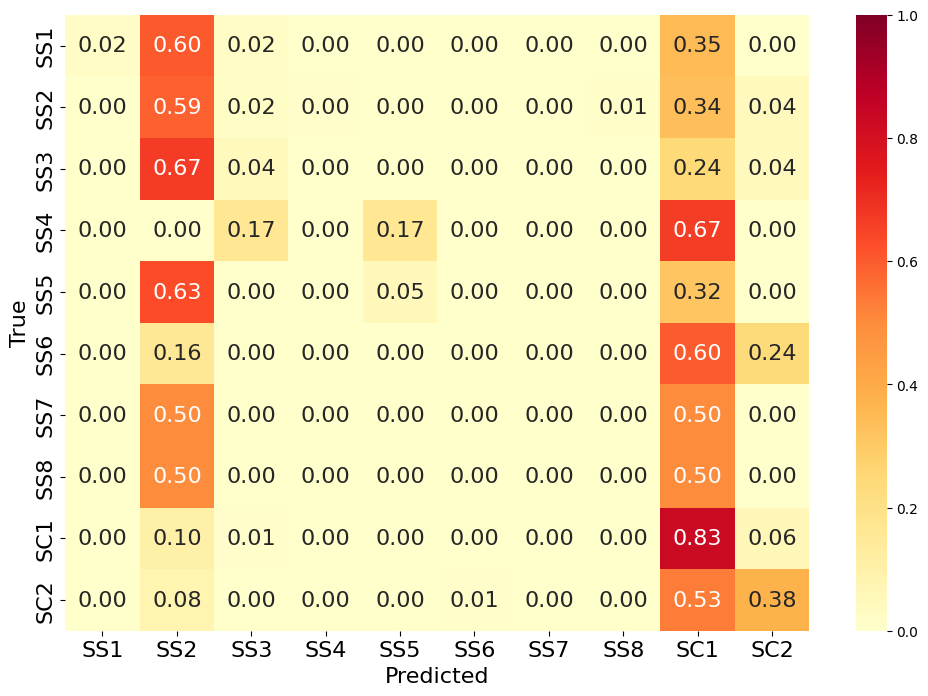

In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

train_df = pd.read_pickle('.../PS_S_df_train_df.pkl')
test_df = pd.read_pickle('.../PS_S_df_test_df.pkl')

label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

results_df = pd.read_csv('.../PS_S_df_train_df_grid_search_details.csv')
print("Reading '.../PS_S_df_train_df_grid_search_details.csv'")
best_row = results_df.loc[results_df['rank_test_score'].idxmin()]
best_params = {col.replace('param_', ''): best_row[col] for col in results_df.columns if col.startswith('param_')}
best_params = {k: (None if pd.isna(v) else v) for k, v in best_params.items()}
best_params['max_depth'] = int(best_params['max_depth']) if best_params['max_depth'] is not None else None
print("Best Parameters:", best_params)

X_train = np.vstack(train_df['TFIDF Vector'].values)
y_train = train_df['label']
X_test = np.vstack(test_df['TFIDF Vector'].values)
y_test = test_df['label']

rf_classifier = RandomForestClassifier(**best_params, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)

def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}
    if isinstance(preds, pd.Series):
        preds = preds.to_numpy()
    if isinstance(labels, pd.Series):
        labels = labels.to_numpy()

    preds_flat = preds.flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        accuracy = np.sum(y_preds == label) / len(y_true) * 100 if len(y_true) > 0 else 0
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds == label])}/{len(y_true)} = {accuracy:.1f}% \n')

y_true_binarized = label_binarize(y_test, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(y_pred, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

# Print the classification report and confusion matrix
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

auroc_per_class = {}
for i, label in enumerate(label_dict.keys()):
    class_auroc = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    auroc_per_class[label] = class_auroc
    print(f"AUROC for {label}: {class_auroc:.3f}")

class_counts = np.bincount(y_test)
class_weights = class_counts / len(y_test)
weighted_auroc = np.sum([class_weights[i] * auroc_per_class[label] for i, label in enumerate(label_dict.keys())])

print(f"Weighted AUROC: {weighted_auroc:.3f}")

def per_class_accuracy(cm):
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (FP + FN + TP)
    per_class_acc = (TP + TN) / np.sum(cm)
    return per_class_acc

per_class_acc = per_class_accuracy(cm)
for i, label in enumerate(label_dict.keys()):
    print(f"Per-class accuracy for {label}: {per_class_acc[i]:.3f}")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.show()

# **Classification on Affective Dimension**

## *Gridsearch for best hyperparameters using train_df*

In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
df = pd.read_pickle('.../AFFECTIVE_df_train.pkl')

X = np.vstack(df['TFIDF Vector'].values)
y = df['label']

sss = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=sss, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best CV Score:", best_score)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df.to_csv('.../affective_train_df_grid_search_details.csv', index=False)
print(f'Grid search result saved in .../affective_train_df_grid_search_details.csv')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score: 0.8952380952380952
Grid search result saved in /content/drive/MyDrive/AIED25/M1_RF_TFIDF/affective_train_df_grid_search_details.csv


## *Running RF with best performing hyperparameters*

Reading '/content/drive/MyDrive/AIED25/M1_RF_TFIDF/affective_train_df_grid_search_details.csv'
Best Parameters: {'max_depth': 30, 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(10), 'n_estimators': np.int64(200)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

         AS1      0.935     0.763     0.841       114
         AS2      0.836     0.967     0.897       184
         AS3      0.000     0.000     0.000         8

   micro avg      0.866     0.866     0.866       306
   macro avg      0.590     0.577     0.579       306
weighted avg      0.851     0.866     0.852       306
 samples avg      0.866     0.866     0.866       306

Accuracy: 0.866
Precision: 0.851
Recall: 0.866
F1 Score: 0.852

AUROC for AS1: 0.937
AUROC for AS2: 0.919
AUROC for AS3: 0.980
Weighted AUROC: 0.927
Per-class accuracy for AS1: 0.892
Per-class accuracy for AS2: 0.866
Per-class accuracy for AS3: 0.974


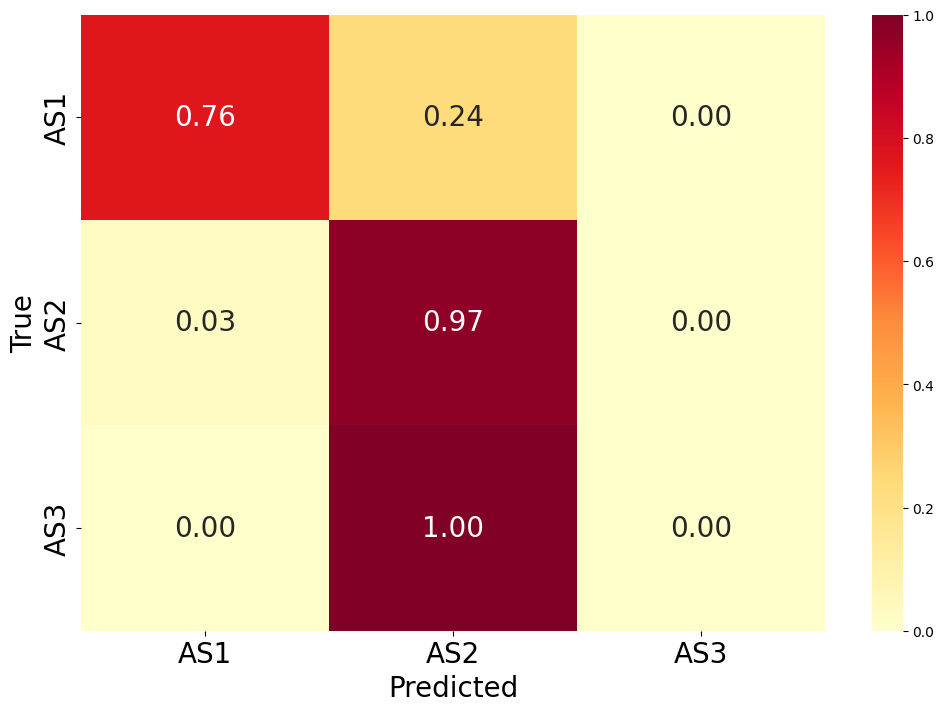

In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

train_df = pd.read_pickle('.../AFFECTIVE_df_train.pkl')
test_df = pd.read_pickle('.../AFFECTIVE_df_test.pkl')

label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}
results_df = pd.read_csv('.../affective_train_df_grid_search_details.csv')
print("Reading '.../affective_train_df_grid_search_details.csv'")

best_row = results_df.loc[results_df['rank_test_score'].idxmin()]
best_params = {col.replace('param_', ''): best_row[col] for col in results_df.columns if col.startswith('param_')}
best_params = {k: (None if pd.isna(v) else v) for k, v in best_params.items()}
best_params['max_depth'] = int(best_params['max_depth']) if best_params['max_depth'] is not None else None
print("Best Parameters:", best_params)

X_train = np.vstack(train_df['TFIDF Vector'].values)
y_train = train_df['label']
X_test = np.vstack(test_df['TFIDF Vector'].values)
y_test = test_df['label']

rf_classifier = RandomForestClassifier(**best_params, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)

def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}
    if isinstance(preds, pd.Series):
        preds = preds.to_numpy()
    if isinstance(labels, pd.Series):
        labels = labels.to_numpy()
    preds_flat = preds.flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        accuracy = np.sum(y_preds == label) / len(y_true) * 100 if len(y_true) > 0 else 0
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds == label])}/{len(y_true)} = {accuracy:.1f}% \n')

y_true_binarized = label_binarize(y_test, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(y_pred, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

auroc_per_class = {}
for i, label in enumerate(label_dict.keys()):
    class_auroc = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    auroc_per_class[label] = class_auroc
    print(f"AUROC for {label}: {class_auroc:.3f}")

class_counts = np.bincount(y_test)
class_weights = class_counts / len(y_test)
weighted_auroc = np.sum([class_weights[i] * auroc_per_class[label] for i, label in enumerate(label_dict.keys())])

print(f"Weighted AUROC: {weighted_auroc:.3f}")

def per_class_accuracy(cm):
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (FP + FN + TP)
    per_class_acc = (TP + TN) / np.sum(cm)
    return per_class_acc

per_class_acc = per_class_accuracy(cm)
for i, label in enumerate(label_dict.keys()):
    print(f"Per-class accuracy for {label}: {per_class_acc[i]:.3f}")

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.show()